Реализовать сеть Хемминга для распознавания индекса. Проверить работу сети на зашумленных изображениях.

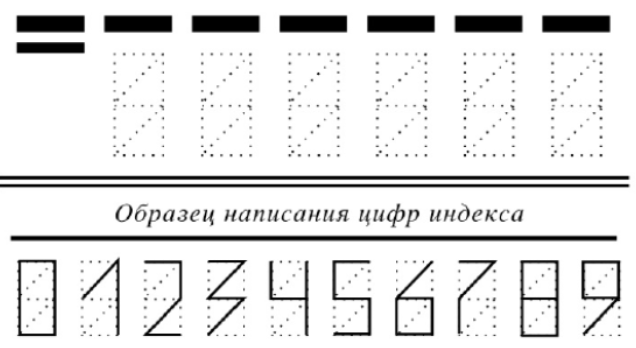

In [ ]:
import numpy as np

In [ ]:
def print_image(vector):
    matrix = vector.reshape((5, 3))
    for row in matrix:
        print(" ".join(["██" if val == 1 else "  " for val in row]))
    print("-" * 25)

####Эталонные выборки

Т.к. сами цифры имеют размер 12х6, сделаем в размере 5х3

In [ ]:
n0 = np.array([
     1, 1, 1,
     1,-1, 1,
     1,-1, 1,
     1,-1, 1,
     1, 1, 1
])

n1 = np.array([
    -1,-1, 1,
    -1, 1, 1,
     1,-1, 1,
    -1,-1, 1,
    -1,-1, 1
])

n2 = np.array([
      1, 1, 1,
     -1,-1, 1,
     -1, 1,-1,
      1,-1,-1,
      1, 1, 1
])

n3 = np.array([
      1, 1, 1,
     -1, 1,-1,
      1, 1, 1,
     -1, 1,-1,
      1,-1,-1
])

n4 = np.array([
      1,-1, 1,
      1,-1, 1,
      1, 1, 1,
     -1,-1, 1,
     -1,-1, 1
])

n5 = np.array([
      1, 1, 1,
      1,-1,-1,
      1, 1, 1,
     -1,-1, 1,
      1, 1, 1
])

n6 = np.array([
     -1,-1, 1,
     -1, 1,-1,
      1, 1, 1,
      1,-1, 1,
      1, 1, 1
])

n7 = np.array([
      1, 1, 1,
     -1,-1, 1,
     -1, 1,-1,
      1,-1,-1,
      1,-1,-1
])

n8 = np.array([
      1, 1, 1,
      1,-1, 1,
      1, 1, 1,
      1,-1, 1,
      1, 1, 1
])

n9 = np.array([
      1, 1, 1,
      1,-1, 1,
      1, 1, 1,
     -1, 1,-1,
      1,-1,-1
])

# 1
X = [n0,n1,n2,n3,n4,n5,n6,n7,n8,n9]

for i in X:
  print_image(i)

██ ██ ██
██    ██
██    ██
██    ██
██ ██ ██
-------------------------
      ██
   ██ ██
██    ██
      ██
      ██
-------------------------
██ ██ ██
      ██
   ██   
██      
██ ██ ██
-------------------------
██ ██ ██
   ██   
██ ██ ██
   ██   
██      
-------------------------
██    ██
██    ██
██ ██ ██
      ██
      ██
-------------------------
██ ██ ██
██      
██ ██ ██
      ██
██ ██ ██
-------------------------
      ██
   ██   
██ ██ ██
██    ██
██ ██ ██
-------------------------
██ ██ ██
      ██
   ██   
██      
██      
-------------------------
██ ██ ██
██    ██
██ ██ ██
██    ██
██ ██ ██
-------------------------
██ ██ ██
██    ██
██ ██ ██
   ██   
██      
-------------------------


####Искаженные выборки

In [ ]:
good_test = []

for clean_img in X:
    for variant in range(1):
        noisy_img = clean_img.copy()

        pix_flip = np.random.choice(15, size=2, replace=False)

        for pix in pix_flip:
            noisy_img[pix] *= -1

        good_test.append(noisy_img)

for i in range(len(good_test)):
  print(f"Получившаяся искаженная картинка {i}")
  print_image(good_test[i])


Получившаяся искаженная картинка 0
██ ██ ██
      ██
██ ██ ██
██    ██
██ ██ ██
-------------------------
Получившаяся искаженная картинка 1
      ██
   ██ ██
██    ██
██    ██
   ██ ██
-------------------------
Получившаяся искаженная картинка 2
██    ██
      ██
   ██   
██      
   ██ ██
-------------------------
Получившаяся искаженная картинка 3
██ ██ ██
██      
██ ██ ██
   ██   
██      
-------------------------
Получившаяся искаженная картинка 4
██    ██
      ██
██ ██ ██
        
      ██
-------------------------
Получившаяся искаженная картинка 5
██ ██ ██
██      
██ ██ ██
██    ██
██    ██
-------------------------
Получившаяся искаженная картинка 6
   ██ ██
   ██   
██ ██ ██
      ██
██ ██ ██
-------------------------
Получившаяся искаженная картинка 7
██ ██   
      ██
   ██ ██
██      
██      
-------------------------
Получившаяся искаженная картинка 8
██ ██ ██
██    ██
██ ██ ██
      ██
██ ██   
-------------------------
Получившаяся искаженная картинка 9
██ ██ ██
██

####Сеть Хемминга

1.   Матрица эталонных образов Х размера Kxn, где К - количество эталонных образов, n количество нейронов, здесь X.shape() -> 9*15
2.   Матрица весов нейронов первого слоя W = 0.5*X
3.   Определитель параметра Т = n/2 функции активации

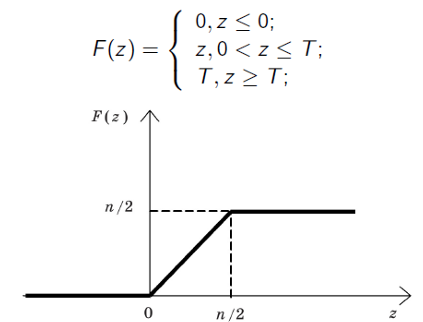

4.   Выход нейронов первого слоя (скрытый слой) Y = F(WX + T), а всего скрытых нейронов 10 штук
5.   Выход первого слоя V.shape -> (10,10), т.к. 10 нейронов
6.   Применяется Евклидово расстояиния ||Yi - Yi-1||^2 <= 0.1



In [ ]:
def fun_Hallming(vector, T):
  example = []
  for elem in vector:
    if elem <= 0:
      example.append(0)
    elif 0 < elem <= T*2:
      example.append(elem)
    else:
      example.append(T*2)
  return np.array(example)

In [ ]:
# Обучение 1,2,3
W = np.dot(0.5, X) # 2
T = 15 / 2 # 3

epsilon = -0.05
V = np.dot(np.ones((10,10)), epsilon)
# V = np.dot(V, epsilon)
np.fill_diagonal(V, 1)
print(f"Получившаяся матрица 1 слоя X:")
print(*X, sep='\n')
print("Получившаяся матрица весов 1 слоя W:")
print(*W, sep='\n')
print(f"Получившаяся матрица выхода V: \n{V}")

Получившаяся матрица 1 слоя X:
[ 1  1  1  1 -1  1  1 -1  1  1 -1  1  1  1  1]
[-1 -1  1 -1  1  1  1 -1  1 -1 -1  1 -1 -1  1]
[ 1  1  1 -1 -1  1 -1  1 -1  1 -1 -1  1  1  1]
[ 1  1  1 -1  1 -1  1  1  1 -1  1 -1  1 -1 -1]
[ 1 -1  1  1 -1  1  1  1  1 -1 -1  1 -1 -1  1]
[ 1  1  1  1 -1 -1  1  1  1 -1 -1  1  1  1  1]
[-1 -1  1 -1  1 -1  1  1  1  1 -1  1  1  1  1]
[ 1  1  1 -1 -1  1 -1  1 -1  1 -1 -1  1 -1 -1]
[ 1  1  1  1 -1  1  1  1  1  1 -1  1  1  1  1]
[ 1  1  1  1 -1  1  1  1  1 -1  1 -1  1 -1 -1]
Получившаяся матрица весов 1 слоя W:
[ 0.5  0.5  0.5  0.5 -0.5  0.5  0.5 -0.5  0.5  0.5 -0.5  0.5  0.5  0.5
  0.5]
[-0.5 -0.5  0.5 -0.5  0.5  0.5  0.5 -0.5  0.5 -0.5 -0.5  0.5 -0.5 -0.5
  0.5]
[ 0.5  0.5  0.5 -0.5 -0.5  0.5 -0.5  0.5 -0.5  0.5 -0.5 -0.5  0.5  0.5
  0.5]
[ 0.5  0.5  0.5 -0.5  0.5 -0.5  0.5  0.5  0.5 -0.5  0.5 -0.5  0.5 -0.5
 -0.5]
[ 0.5 -0.5  0.5  0.5 -0.5  0.5  0.5  0.5  0.5 -0.5 -0.5  0.5 -0.5 -0.5
  0.5]
[ 0.5  0.5  0.5  0.5 -0.5 -0.5  0.5  0.5  0.5 -0.5 -0.5  0.5  0.5  0.5
 

In [ ]:
Y1 = fun_Hallming(np.dot(W, X[0])+T, T)
print(Y1)

[15.  8. 10.  6. 10. 12.  9.  8. 14.  9.]


In [ ]:
def run_Hallming(cartoon_test, W, T, V, max_iter=100):
  res = []
  Y1 = fun_Hallming(np.dot(W, cartoon_test) + T, T)
  Ycurr = Y1.copy()
  #Итерационный процесс на втором слое
  for y in range(max_iter):
    Y2 = fun_Hallming(np.dot(V, Ycurr), T)
    diff = np.sum((Y2 - Ycurr)**2)
    if diff <= 0.1 :
      print("Равновесие произошло")
      res.append(Y2)
      break
    Ycurr = Y2.copy()

  return np.array(res)

Тестируем работу

In [ ]:
a = [99, 0, 23]
i = np.max(a)
c = np.count_nonzero(a == i)
print(c)

1


In [ ]:
sum_pred = 0

for i in range(len(good_test)):
  massive = run_Hallming(good_test[i], W,T,V)
  # np.isclose(massive, np.max(massive), atol=1e-5)
  if np.count_nonzero(massive == np.max(massive)) > 1:
    print("Сеть Хеллмана не смогла классифицировать образ")
    print(f"Исходная картинка #{i}")
    print_image(X[i])
    print(f"Искаженная картинка #{i}")
    print_image(good_test[i])
    print(f"Что получилось в итерационном процессе 2 слоя: \n{massive}")
    print('==='*40)
    print()
  else:
    print(f"Сеть Хеллмана смогла классифицировать - это класс: {np.argmax(massive)}")
    if np.argmax(massive) == i: sum_pred += 1
    print(f"Исходная картинка #{i}")
    print_image(X[i])
    print(f"Искаженная картинка #{i}")
    print_image(good_test[i])
    print(f"Что получилось в итерационном процессе 2 слоя: \n{massive}")
    print('==='*40)
    print()

accuracy = sum_pred / len(X)
print(f"Точность предсказаний: {accuracy}")


Равновесие произошло
Сеть Хеллмана смогла классифицировать - это класс: 8
Исходная картинка #0
██ ██ ██
██    ██
██    ██
██    ██
██ ██ ██
-------------------------
Искаженная картинка #0
██ ██ ██
      ██
██ ██ ██
██    ██
██ ██ ██
-------------------------
Что получилось в итерационном процессе 2 слоя: 
[[1.45890838 0.         0.         0.         0.         0.
  0.         0.         3.16924774 0.        ]]

Равновесие произошло
Сеть Хеллмана смогла классифицировать - это класс: 1
Исходная картинка #1
      ██
   ██ ██
██    ██
      ██
      ██
-------------------------
Искаженная картинка #1
      ██
   ██ ██
██    ██
██    ██
   ██ ██
-------------------------
Что получилось в итерационном процессе 2 слоя: 
[[0.         4.46557758 0.         0.         0.         0.
  2.83668295 0.         0.         0.        ]]

Равновесие произошло
Сеть Хеллмана смогла классифицировать - это класс: 2
Исходная картинка #2
██ ██ ██
      ██
   ██   
██      
██ ██ ██
-------------------------
